In [29]:
from load_data import find_outliers, melt_demand, load_demand_raw, load_demand

find_outliers(melt_demand(load_demand_raw()))

,store,date,pallets
1654,Four Square Ellerslie,2026-06-03,40
2078,Pak 'n Save Henderson,2026-06-10,120


In [30]:
demand_df = load_demand()

display(demand_df[(demand_df["store"] == "Four Square Ellerslie") & (demand_df["date"] == "2026-06-03")])
display(demand_df[(demand_df["store"] == "Pak 'n Save Henderson") & (demand_df["date"] == "2026-06-10")])

,store,date,pallets
1654,Four Square Ellerslie,2026-06-03,4


,store,date,pallets
2078,Pak 'n Save Henderson,2026-06-10,12


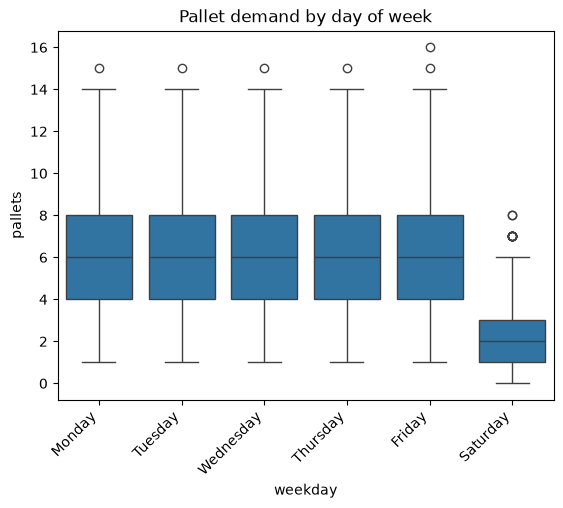

'\nThis pools all 55 stores together into one box per weekday. This is fine for a first look however the problem with this is that a high demand store can mask a low demand store.\n'

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

demand_df["weekday"] = demand_df["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    # "Sunday",
]

sns.boxplot(data=demand_df, x="weekday", y="pallets", order=weekday_order)
plt.title("Pallet demand by day of week")
plt.xticks(rotation=45, ha="right")
plt.show()

"""
This pools all 55 stores together into one box per weekday. This is fine for a first look however the problem with this is that a high demand store can mask a low demand store.
"""

In [32]:
demand_df = load_demand()
demand_df[demand_df["date"] == "2026-06-01"] # Kings Birthday, should return empty df

,store,date,pallets


In [33]:
demand_df = load_demand()
demand_df[(demand_df["store"] == "Pak 'n Save Albany") & (demand_df["date"] == "2026-06-03")] # Where demand exceeds capacity, should return empty df

,store,date,pallets


In [34]:
# noinspection PyInterpreter
from demand_averages import weekday_average, saturday_average
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

demand_df = load_demand()

weekday_avg = weekday_average(demand_df)
saturday_avg = saturday_average(demand_df)

display(weekday_avg)
display(saturday_avg)

,store,huber_mean_pallets,huber_pallets_ceil
0,Four Square Botany Junction,2.641026,3
1,Four Square Britomart,2.325481,3
2,Four Square Cockle Bay,2.256410,3
3,Four Square Eden Terrace,2.523810,3
4,Four Square Ellerslie,2.435897,3
5,Four Square Fair Price Henderson,2.461538,3
6,Four Square Glen Eden,2.589744,3
7,Four Square Hobsonville,2.641026,3
8,Four Square Lancaster,2.444626,3
9,Four Square Onehunga,2.266089,3


,store,huber_mean_pallets,huber_pallets_round
0,Four Square Botany Junction,3.750000e-01,0
1,Four Square Britomart,6.784797e-10,0
2,Four Square Cockle Bay,0.000000e+00,0
3,Four Square Eden Terrace,6.784797e-10,0
4,Four Square Ellerslie,3.750000e-01,0
5,Four Square Fair Price Henderson,3.750000e-01,0
6,Four Square Glen Eden,6.250000e-01,1
7,Four Square Hobsonville,6.250000e-01,1
8,Four Square Lancaster,6.250000e-01,1
9,Four Square Onehunga,3.750000e-01,0


In [35]:
from demand_averages import weekday_average, saturday_average
from load_data import load_durations, load_demand
import pandas as pd
import matplotlib.pyplot as plt

durations_df = load_durations()

demand_df = load_demand()

weekday_avg_df = weekday_average(demand_df)   # one huber_mean_pallets value per store
saturday_avg_df = saturday_average(demand_df)

def driving_budget_per_leg(avg_pallets_per_store, num_stores_on_route,
                            trip_cap_minutes=210, unload_min_per_pallet=18):
    """
    Given an assumed route size (num_stores_on_route) and average pallets
    per store, work out how much of the 3.5hr trip cap is left for driving
    after unloading, and split that evenly across the legs of the route
    (depot -> store1 -> ... -> storeN -> depot = N+1 legs).
    """
    total_unload_min = num_stores_on_route * avg_pallets_per_store * unload_min_per_pallet
    driving_budget_min = trip_cap_minutes - total_unload_min
    num_legs = num_stores_on_route + 1
    return driving_budget_min, driving_budget_min / num_legs


def budget_table(avg_pallets_per_store, label, n_range=range(1, 9)):
    """Build a tidy table of driving budget by route size for a given day-type."""
    rows = []
    for n in n_range:
        budget, per_leg = driving_budget_per_leg(avg_pallets_per_store, n)
        rows.append({"day_type": label, "num_stores": n,
                      "driving_budget_min": budget, "per_leg_min": per_leg})
    return pd.DataFrame(rows)

weekday_table = budget_table(weekday_avg_df["huber_mean_pallets"].mean(), "Weekday")
saturday_table = budget_table(saturday_avg_df["huber_mean_pallets"].mean(), "Saturday")

budget_df = pd.concat([weekday_table, saturday_table], ignore_index=True)
display(weekday_table)
saturday_table

,day_type,num_stores,driving_budget_min,per_leg_min
0,Weekday,1,100.199337,50.099669
1,Weekday,2,-9.601325,-3.200442
2,Weekday,3,-119.401988,-29.850497
3,Weekday,4,-229.202651,-45.840530
4,Weekday,5,-339.003313,-56.500552
5,Weekday,6,-448.803976,-64.114854
6,Weekday,7,-558.604638,-69.825580
7,Weekday,8,-668.405301,-74.267256


,day_type,num_stores,driving_budget_min,per_leg_min
0,Saturday,1,167.482796,83.741398
1,Saturday,2,124.965591,41.655197
2,Saturday,3,82.448387,20.612097
3,Saturday,4,39.931182,7.986236
4,Saturday,5,-2.586022,-0.431004
5,Saturday,6,-45.103226,-6.443318
6,Saturday,7,-87.620431,-10.952554
7,Saturday,8,-130.137635,-14.459737


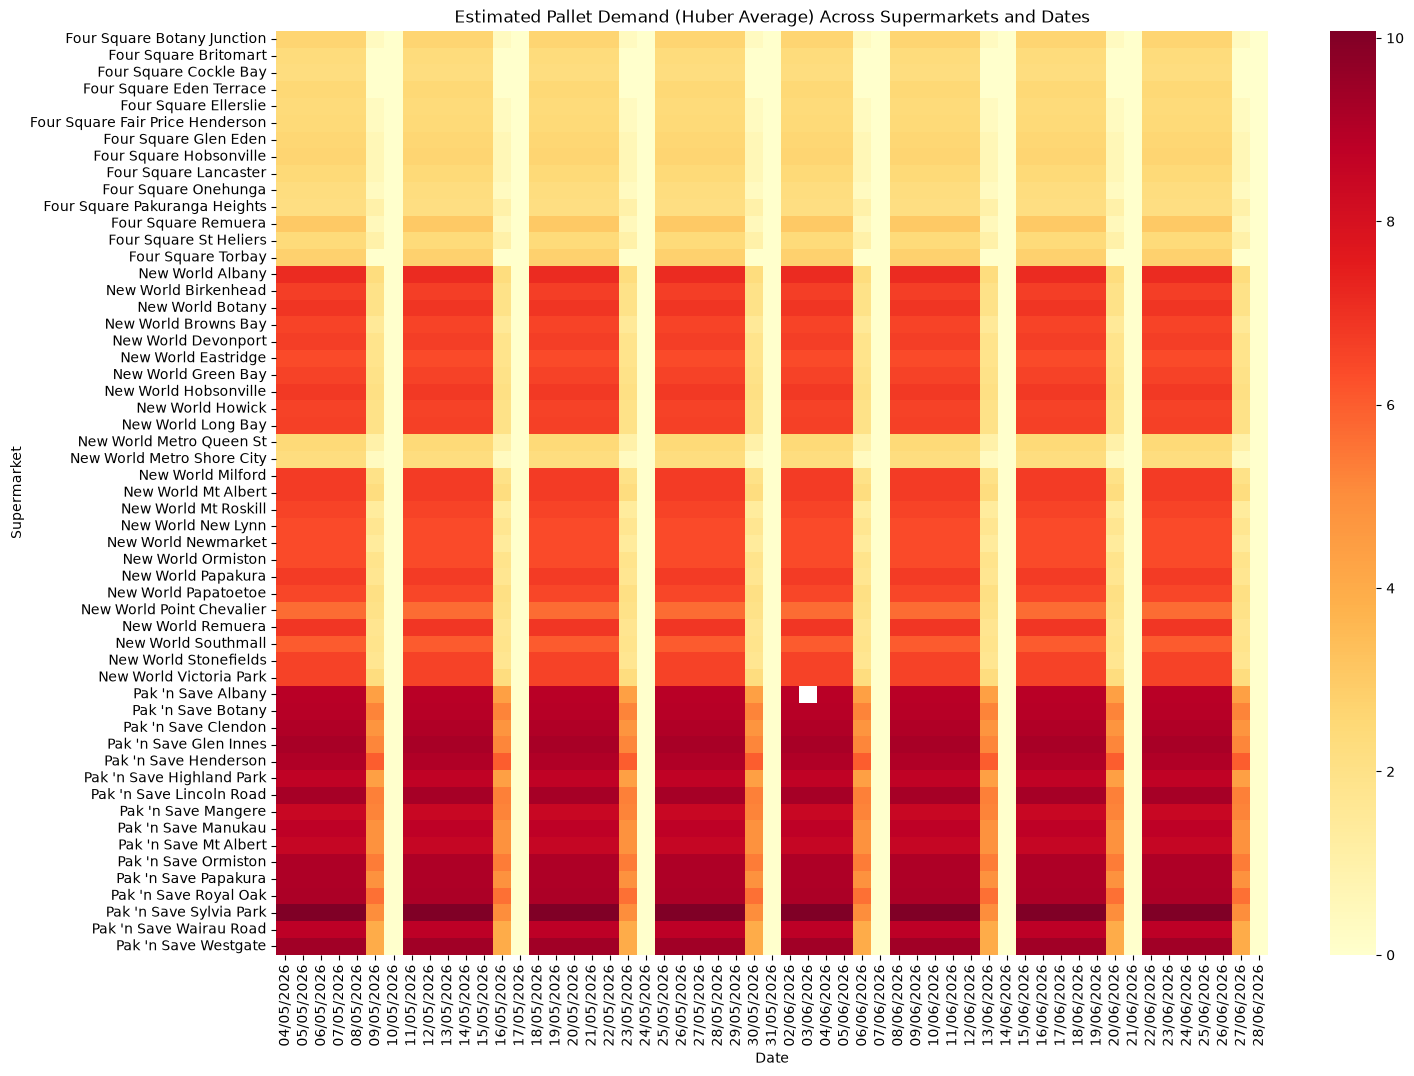

In [36]:
import seaborn as sns
import numpy as np

demand_df = load_demand()

weekday_avg = weekday_average(demand_df).set_index("store")["huber_mean_pallets"]
saturday_avg = saturday_average(demand_df).set_index("store")["huber_mean_pallets"]

def estimated_value(row):
    wd = row["date"].weekday()
    if wd < 5:
        return weekday_avg.get(row["store"], np.nan)
    elif wd == 5:
        return saturday_avg.get(row["store"], np.nan)
    return 0  # Sunday — no deliveries

demand_df["estimated_pallets"] = demand_df.apply(estimated_value, axis=1)

pivot_df = demand_df.pivot_table(index="store", columns="date", values="estimated_pallets")
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)
pivot_df.columns = pivot_df.columns.strftime("%d/%m/%Y")

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(pivot_df, cmap="YlOrRd", ax=ax)
ax.set_title("Estimated Pallet Demand (Huber Average) Across Supermarkets and Dates")
ax.set_xlabel("Date")
ax.set_ylabel("Supermarket")
plt.show()

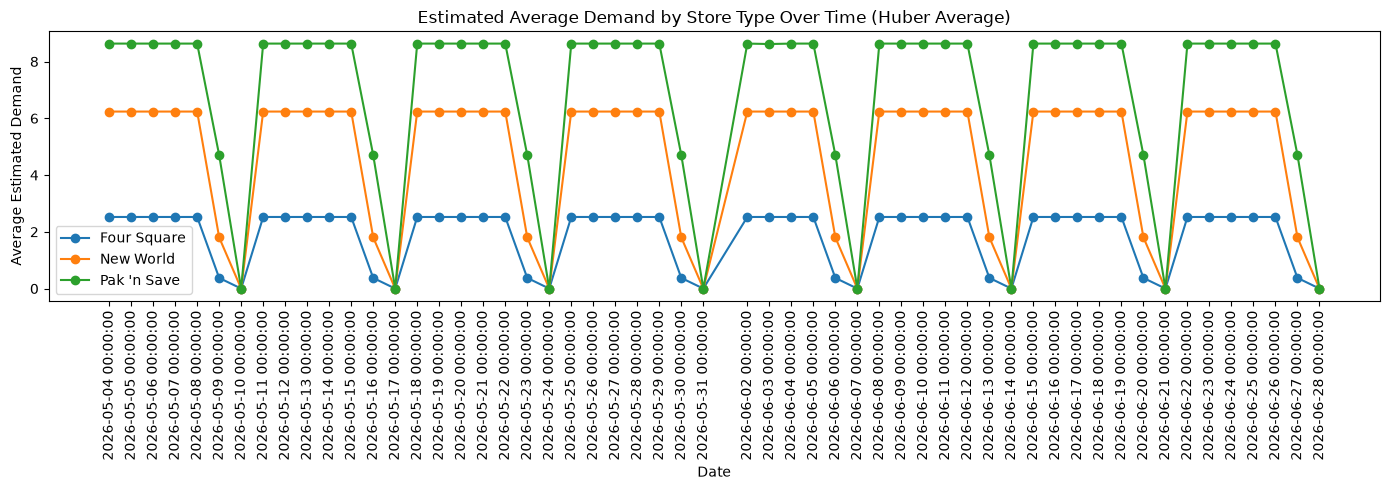

In [37]:
def store_type(store_name):
    if "Pak" in store_name:
        return "Pak 'n Save"
    elif "New World" in store_name:
        return "New World"
    elif "Four Square" in store_name:
        return "Four Square"
    return "Other"

demand_df["store_type"] = demand_df["store"].apply(store_type)

type_avg_est = demand_df.groupby(["date", "store_type"])["estimated_pallets"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in type_avg_est.groupby("store_type"):
    ax.plot(group["date"], group["estimated_pallets"], marker="o", label=label)
ax.set_xlabel("Date")
ax.set_ylabel("Average Estimated Demand")
ax.set_title("Estimated Average Demand by Store Type Over Time (Huber Average)")
ax.legend()

demand_df["date"] = pd.to_datetime(demand_df["date"]).dt.normalize()
ax.set_xticks(type_avg_est["date"].unique())
ax.set_xticklabels(type_avg_est["date"].unique(), rotation=90)

plt.tight_layout()
plt.show()

In [38]:
def matches_used_estimate(row):
    """Check if the estimate actually used in route generation
    (ceil for weekday, round for Saturday) matches actual demand."""
    wd = row["date"].weekday()
    if wd < 5:
        used_estimate = np.ceil(weekday_avg.get(row["store"], np.nan))
    elif wd == 5:
        used_estimate = np.round(saturday_avg.get(row["store"], np.nan))
    else:
        return True  # Sunday, always 0 vs 0
    return row["pallets"] == used_estimate

demand_df["outcome"] = demand_df.apply(
    lambda row: "Exact (matches routing estimate)" if matches_used_estimate(row)
    else ("Undershoot (est. too low)" if row["pallets"] > row["estimated_pallets"]
          else "Overshoot (est. too high)"),
    axis=1
)

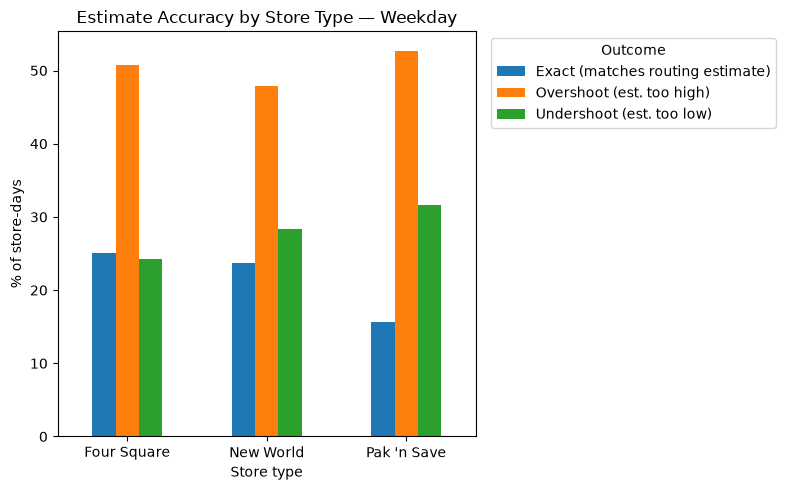

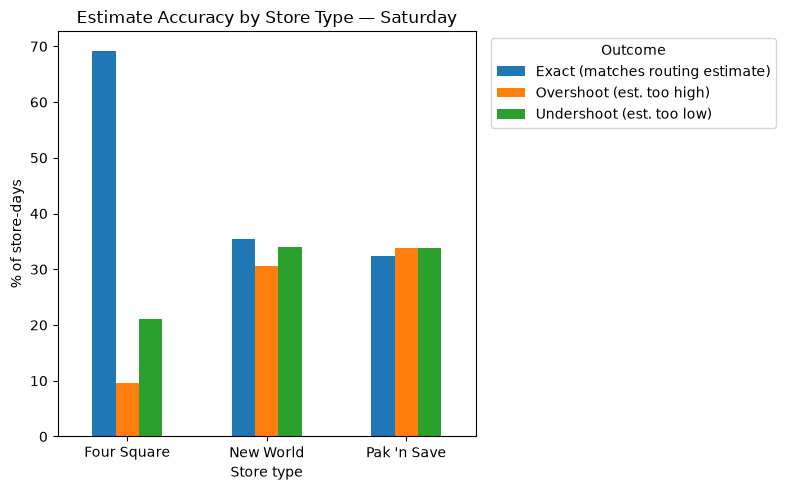

In [39]:
# outcome_by_type = (
#     demand_df[demand_df["date"].dt.weekday != 6]  # exclude Sunday, trivially exact
#     .groupby("store_type")["outcome"]
#     .value_counts(normalize=True)
#     .unstack() * 100
# )
#
# fig, ax = plt.subplots(figsize=(8, 5))
# outcome_by_type.plot(kind="bar", ax=ax)
# ax.set_ylabel("% of store-days")
# ax.set_xlabel("Store type")
# ax.set_title("Estimate Accuracy by Store Type (Huber Average vs Actual Demand)")
# ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

weekday_df = demand_df[demand_df["date"].dt.weekday < 5]
saturday_df = demand_df[demand_df["date"].dt.weekday == 5]

def plot_outcome_by_type(df, title):
    outcome_by_type = (
        df.groupby("store_type")["outcome"]
        .value_counts(normalize=True)
        .unstack() * 100
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    outcome_by_type.plot(kind="bar", ax=ax)
    ax.set_ylabel("% of store-days")
    ax.set_xlabel("Store type")
    ax.set_title(title)
    ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_outcome_by_type(weekday_df, "Estimate Accuracy by Store Type — Weekday")
plot_outcome_by_type(saturday_df, "Estimate Accuracy by Store Type — Saturday")

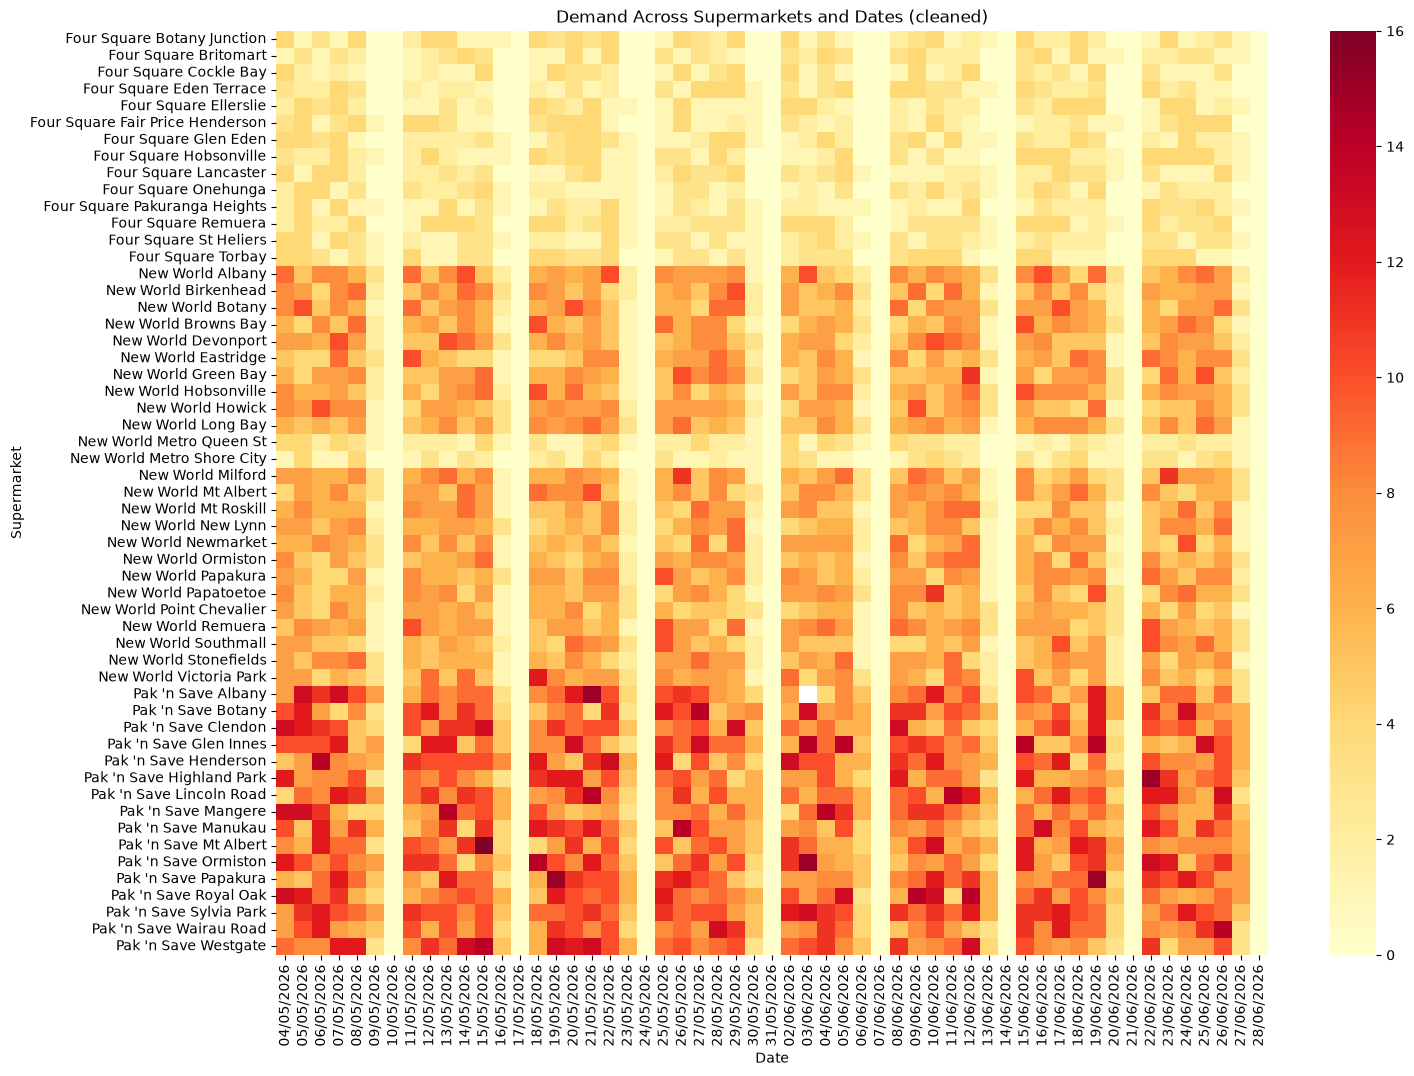

In [40]:
import seaborn as sns

demand_df = load_demand()  # cleaned: typos fixed, Albany-17 dropped, King's Birthday dropped

pivot_df = demand_df.pivot_table(index="store", columns="date", values="pallets")
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)
pivot_df.columns = pivot_df.columns.strftime("%d/%m/%Y")

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(pivot_df, cmap="YlOrRd", ax=ax)
ax.set_title("Demand Across Supermarkets and Dates (cleaned)")
ax.set_xlabel("Date")
ax.set_ylabel("Supermarket")
plt.show()

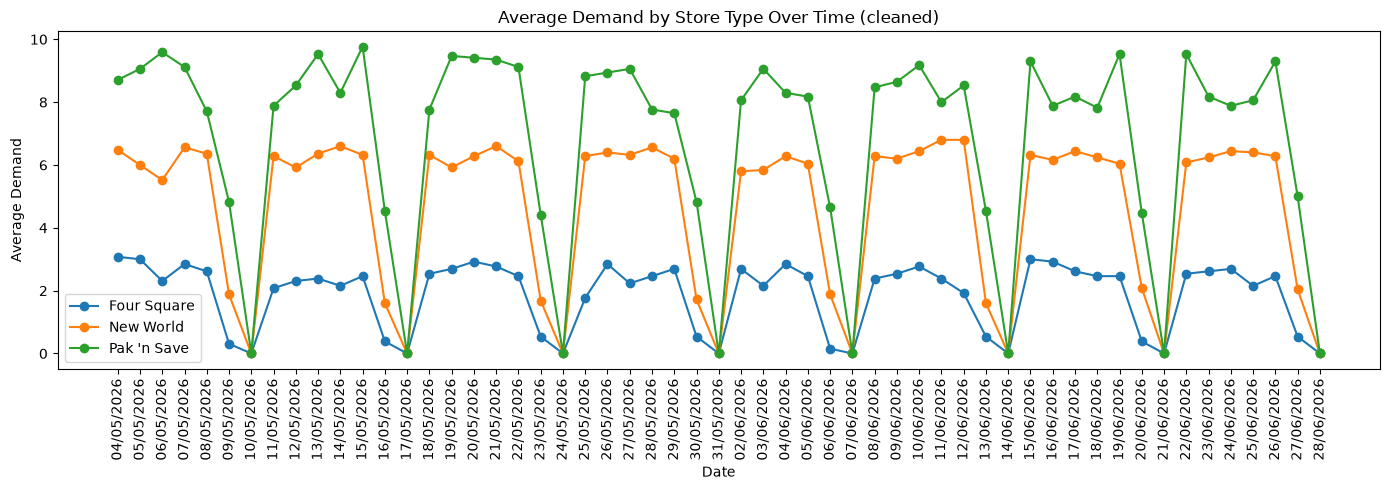

In [42]:
def store_type(store_name):
    if "Pak" in store_name:
        return "Pak 'n Save"
    elif "New World" in store_name:
        return "New World"
    elif "Four Square" in store_name:
        return "Four Square"
    return "Other"

demand_df["store_type"] = demand_df["store"].apply(store_type)

type_avg = demand_df.groupby(["date", "store_type"])["pallets"].mean().reset_index()

type_avg["date_str"] = type_avg["date"].dt.strftime("%d/%m/%Y")

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in type_avg.groupby("store_type"):
    ax.plot(group["date_str"], group["pallets"], marker="o", label=label)

ax.set_xlabel("Date")
ax.set_ylabel("Average Demand")
ax.set_title("Average Demand by Store Type Over Time (cleaned)")
ax.legend()

# force every date to show as a tick
unique_dates = sorted(type_avg["date_str"].unique())
ax.set_xticks(unique_dates)
ax.set_xticklabels(unique_dates, rotation=90)

plt.tight_layout()
plt.show()